# Feature Visualization

This notebook loads:
1. Trained probe weights and configurations from WandB
2. Activations from HuggingFace  
3. Questions, labels, and model outputs from the dataset files

In [ ]:
from huggingface_hub import login
login(token="")

In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import torch
import tqdm

import probe_gen.probes as probes
from probe_gen.config import ConfigDict, data
from probe_gen.standard_experiments.hyperparameter_search import get_best_hyperparams_for_train_setup

# Configuration for feature visualization
probe_type = "mean"  # Options: "mean", "attention_torch", "mean_torch"
behaviour = "science"
datasource = "ultrachat"
activations_model = "llama_3b"
generation_method = "on_policy"
response_model = "llama_3b"
mode = "train"

## 1. Train a probe


In [2]:
from probe_gen.standard_experiments.token_heatmaps import train_probe_on

probe = train_probe_on(probe_type, behaviour, datasource, activations_model, generation_method, response_model, mode, verbose=True)

Loaded hyperparameters:
  Layer: 12
  Use bias: True
  Normalize: True
  C (inverse ofregularization): 0.01
loaded activations with shape torch.Size([5000, 257, 3072])
calculated attention mask with shape torch.Size([5000, 257])
loaded labels

Loaded data:
  Activations shape: torch.Size([5000, 257, 3072])
  Attention mask shape: torch.Size([5000, 257])
  Labels shape: torch.Size([5000])
  Positive samples: 2500
  Negative samples: 2500
Aggregated activations shape: torch.Size([5000, 3072])
Train: 3500 samples, 1750.0 positives
Val:   500 samples, 250.0 positives
Test:  0 samples, 0.0 positives

Training probe...

✓ Validation ROC-AUC: 0.9447
  Accuracy: 0.8560


## 2. Load Activations and Labelled Responses from HuggingFace

Load the pre-computed activations at the specified layer


In [3]:
from probe_gen.standard_experiments.token_heatmaps import load_labelled_responses_and_activations
responses_df, activations_tensor, attention_mask, labels_tensor = load_labelled_responses_and_activations(
    probe_type, behaviour, datasource, activations_model, generation_method, response_model, mode, verbose=False
)

## 5. Extract Probe Weights

Extract the learned weights from the trained probe for visualization


In [4]:
from probe_gen.standard_experiments.token_heatmaps import extract_probe_weights
probe_weights, probe_bias = extract_probe_weights(probe)

## 7. Visualize Probe Scores for Question + Answer Pairs

This cell shows how to compute and visualize probe scores for both the question and answer together


In [5]:
from probe_gen.gen_data.utils import get_pad_token
from probe_gen.standard_experiments.token_heatmaps import get_probe_scores_and_tokens
from transformers import AutoTokenizer

model_name = "meta-llama/Llama-3.2-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "left"
tokenizer.pad_token = get_pad_token(model_name, tokenizer)

scores, tokens = get_probe_scores_and_tokens(tokenizer, 0, responses_df, activations_tensor, probe)

print(f"{'='*90}")
print(f"PROBE SCORES FOR QUESTION + ANSWER ({len(tokens)} tokens)")
print(f"{'='*90}\n")

# For each token, get the probe score:
for i, (score, token) in enumerate(zip(scores, tokens)):
    print(f"Token {i:3d}: {token:25s} -> Probe score: {score:7.3f}")


PROBE SCORES FOR QUESTION + ANSWER (138 tokens)

Token   0: <|begin_of_text|>         -> Probe score: -14.074
Token   1: <|begin_of_text|>         -> Probe score: -14.074
Token   2: <|start_header_id|>       -> Probe score:   0.497
Token   3: system                    -> Probe score:   0.733
Token   4: <|end_header_id|>         -> Probe score:   0.569
Token   5: \n\n                      -> Probe score:   0.489
Token   6: Cut                       -> Probe score:   1.024
Token   7: ting                      -> Probe score:   0.976
Token   8:  Knowledge                -> Probe score:   1.008
Token   9:  Date                     -> Probe score:   1.403
Token  10: :                         -> Probe score:   1.126
Token  11:  December                 -> Probe score:   1.154
Token  12:                           -> Probe score:   1.044
Token  13: 202                       -> Probe score:   0.499
Token  14: 3                         -> Probe score:   0.911
Token  15: \n                       

## 9. Compare Probe Scores: Label=1 vs Label=0

Analyze 10 examples from each class to see how probe scores differ


In [6]:
# # Find indices for label=1 and label=0
# label_1_indices = [i for i, label in enumerate(labels_tensor) if label.item() == 1]
# label_0_indices = [i for i, label in enumerate(labels_tensor) if label.item() == 0]

# print(f"Found {len(label_1_indices)} examples with label=1")
# print(f"Found {len(label_0_indices)} examples with label=0\n")

# # Analyze 10 examples from each class
# n_examples = 10
# results_label_1 = [analyze_example(idx) for idx in label_1_indices[:n_examples]]
# results_label_0 = [analyze_example(idx) for idx in label_0_indices[:n_examples]]

## 13. Token-Level Heatmap Visualization

Visualize complete question and answer with color-coded token probabilities


In [7]:
# Create matplotlib heatmap visualization showing FULL question and answer
# Only visualizes CORRECTLY CLASSIFIED examples
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib.colors import LinearSegmentedColormap
# from transformers import AutoTokenizer
# import os

# from probe_gen.paths import data

# tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")

# def get_correctly_classified_indices(label_value, threshold=0.0):
#     """Get indices of correctly classified examples for a given label"""
#     correctly_classified = []
    
#     for idx in range(len(labels_tensor)):
#         true_label = labels_tensor[idx].item()
        
#         # Only consider examples with the target label
#         if true_label != label_value:
#             continue
        
#         # Get probe's prediction using mean-aggregated activation
#         mean_activation = activations_aggregated[idx].numpy()
#         sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
#         predicted_label = 1 if sequence_score > threshold else 0
        
#         # Check if correctly classified
#         if predicted_label == true_label:
#             correctly_classified.append(idx)
    
#     return correctly_classified

# def visualize_token_heatmap(idx, figsize=(20, 12), save_dir='heatmap_visualizations', model_name = "Llama-3.2-3B-Instruct", dataset_name = "writingprompts", behavior = "lists", generation_method = "on_policy", probe_type = "mean"):
#     """Create a matplotlib heatmap of token probabilities for the ENTIRE question and answer"""
#     question = dataset_df.iloc[idx]['input_formatted']
#     answer = dataset_df.iloc[idx]['model_outputs']
#     label = labels_tensor[idx].item()
    
#     # Get probe's prediction to verify correct classification
#     mean_activation = activations_aggregated[idx].numpy()
#     sequence_score = np.dot(mean_activation, probe_weights) + probe_bias
#     sequence_prob = sigmoid(sequence_score)
#     predicted_label = 1 if sequence_score > 0 else 0
#     is_correct = (predicted_label == label)
    
#     # Determine pos/neg classification
#     pos_neg = 'pos' if label == 1 else 'neg'
    
#     # Print the FULL text
#     print(f"\n{'='*120}")
#     print(f"EXAMPLE {idx} - TRUE LABEL: {label} | PROBE PREDICTION: {predicted_label} | {'✓ CORRECT' if is_correct else '✗ INCORRECT'}")
#     print(f"Probe score: {sequence_score:.3f} | Probability: {sequence_prob:.3f}")
#     print(f"{'='*120}\n")
    
#     # Print COMPLETE question
#     print(f"{'='*120}")
#     print(f"COMPLETE QUESTION:")
#     print(f"{'='*120}")
#     print(question)
#     print(f"{'='*120}\n")
    
#     # Print COMPLETE answer
#     print(f"{'='*120}")
#     print(f"COMPLETE ANSWER:")
#     print(f"{'='*120}")
#     print(answer)
#     print(f"{'='*120}\n")
    
#     full_text = question + " " + answer
#     tokens = tokenizer.tokenize(full_text)

#     question_ids = tokenizer.encode(question, add_special_tokens=False)
#     full_ids = tokenizer.encode(full_text, add_special_tokens=False)

   
#     num_question_tokens = len(question_ids)
    
#     # convert ids back to token strings for display
#     tokens = [tokenizer.decode([token_id]) for token_id in full_ids]
#     ####
    
#     # Get all available tokens (limited by activation tensor size)
#     max_activations = int(attention_mask[idx].sum().item())
#     total_tokens = len(tokens)
#     num_real_tokens = min(total_tokens, max_activations)
    
#     # Warn if truncated
#     if total_tokens > num_real_tokens:
#         print(f"⚠️  NOTE: Full text has {total_tokens} tokens, but activation tensor only has {num_real_tokens} tokens.")
#         print(f"    Heatmap will visualize first {num_real_tokens} tokens only.\n")
#         print(f"{'='*120}\n")
    
#     # Compute scores and probabilities
#     token_texts = []
#     probs = []
#     sections = []
    
#     for i in range(num_real_tokens):
#         activation = activations_tensor[idx][i]
#         score = np.dot(activation.numpy(), probe_weights) + probe_bias
        
#         if abs(score) < 10:  # Skip outliers
#             prob = sigmoid(score)
#             token_text = tokens[i].replace('Ġ', ' ').replace('Ċ', '\\n')
            
#             token_texts.append(token_text)
#             probs.append(prob)
#             sections.append('Q' if i < num_question_tokens else 'A')
    
#     # Create custom colormap: red (0) -> white (0.5) -> blue (1)
#     colors = ['#ff4444', '#ffffff', '#4444ff']
#     n_bins = 100
#     cmap = LinearSegmentedColormap.from_list('prob_cmap', colors, N=n_bins)
    
#     # Dynamically calculate figure height based on number of tokens and wrapping
#     max_width = 100  # Maximum width before wrapping
#     estimated_rows = sum(len(t) * 0.6 + 0.1 for t in token_texts) / max_width + 1
#     dynamic_height = max(12, estimated_rows * 1.2)  # At least 12, scale with content
    
#     # Create figure with dynamic height
#     fig, ax = plt.subplots(figsize=(figsize[0], dynamic_height))
    
#     # Plot tokens as colored rectangles
#     x_pos = 0
#     y_pos = 0
    
#     for i, (token, prob, section) in enumerate(zip(token_texts, probs, sections)):
#         # Wrap to new line if needed
#         if x_pos > max_width:
#             x_pos = 0
#             y_pos -= 1
        
#         # Determine width based on token length
#         token_width = max(len(token) * 0.6, 0.5)
        
#         # Color based on probability
#         color = cmap(prob)
        
#         # Draw rectangle
#         rect = mpatches.Rectangle((x_pos, y_pos), token_width, 0.8, 
#                                   facecolor=color, edgecolor='gray', linewidth=0.5)
#         ax.add_patch(rect)
        
#         # Add text
#         ax.text(x_pos + token_width/2, y_pos + 0.4, token, 
#                ha='center', va='center', fontsize=8, 
#                fontfamily='monospace', weight='bold' if section == 'Q' else 'normal')
        
#         x_pos += token_width + 0.1
    
#     # Set axis properties with enough vertical space
#     ax.set_xlim(0, max_width)
#     ax.set_ylim(y_pos - 1.5, 1)  # Extra space at bottom
#     ax.axis('off')
    
#     # Calculate statistics
#     q_probs = [p for p, s in zip(probs, sections) if s == 'Q']
#     a_probs = [p for p, s in zip(probs, sections) if s == 'A']
    
#     # Add title and legend
#     title = f'Token-Level Probe Probabilities - Example {idx} (Label={label}, Prediction={predicted_label})\n'
#     title += f'Showing {len(token_texts)} tokens (Question: {len(q_probs)}, Answer: {len(a_probs)})'
#     if total_tokens > num_real_tokens:
#         title += f' - Truncated from {total_tokens} total tokens'
#     ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
#     # Create colorbar
#     sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
#     sm.set_array([])
#     cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=50)
#     cbar.set_label('Probability (sigmoid of probe score)', fontsize=12, fontweight='bold')
#     cbar.ax.tick_params(labelsize=10)
    
#     # Add text box with statistics
#     stats_text = f'Question tokens: {len(q_probs)}, Mean prob: {np.mean(q_probs):.3f}\n'
#     stats_text += f'Answer tokens: {len(a_probs)}, Mean prob: {np.mean(a_probs):.3f}\n'
#     stats_text += f'Overall mean: {np.mean(probs):.3f}'
    
#     ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
#            fontsize=10, verticalalignment='top', horizontalalignment='right',
#            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
#     plt.tight_layout()
    
#     # Save figure with descriptive filename
#     save_dir = data.data / "figures" / save_dir / probe_type / behaviour / pos_neg
#     filename = f"{model_name}_{dataset_name}_{probe_type}_{activations_model}_{generation_method}.png"
#     # Clean filename (remove problematic characters)
#     filename = filename.replace('/', '_').replace('\\', '_').replace(' ', '_')
#     filepath = os.path.join(save_dir, filename)
    
#     plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
#     print(f"✓ Figure saved to: {filepath}\n")
    
#     plt.show()

In [ ]:
# Get correctly classified examples for each label
# print("Finding correctly classified examples...")

# correctly_classified_label_1 = get_correctly_classified_indices(label_value=1, threshold=0.0)
# correctly_classified_label_0 = get_correctly_classified_indices(label_value=0, threshold=0.0)

# print(f"✓ Found {len(correctly_classified_label_1)} correctly classified label=1 examples")
# print(f"✓ Found {len(correctly_classified_label_0)} correctly classified label=0 examples")
# print(f"\nThese examples will be used for visualization in the next cell.")


Finding correctly classified examples...
✓ Found 2500 correctly classified label=1 examples
✓ Found 145 correctly classified label=0 examples

These examples will be used for visualization in the next cell.


## 14. Visualize Additional Correctly Classified Examples

Explore more correctly classified examples by changing the index below


In [9]:
import json

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the JSONL file that contains questions, model outputs, and labels from HuggingFace
from huggingface_hub import hf_hub_download
from matplotlib.colors import LinearSegmentedColormap

import probe_gen.probes as probes
from probe_gen.config import ConfigDict
from probe_gen.gen_data.utils import format_prompts_from_pairs

def visualize_token_heatmap(
    tokenizer,
    index,
    responses_df,
    activations_tensor,
    probe,
    labels_tensor,
    figsize=(20, 12),
    ):

    """Create a matplotlib heatmap of token probabilities for the ENTIRE question and answer"""

    label = labels_tensor[index].item()
    predicted_label = probe.predict(activations_tensor[index].mean(dim=0).unsqueeze(0))[0].item()
    scores, tokens = get_probe_scores_and_tokens(tokenizer, index, responses_df, activations_tensor, probe)
    
    # Create custom colormap: red (0) -> white (0.5) -> blue (1)
    colors = ['#ff4444', '#ffffff', '#4444ff']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('prob_cmap', colors, N=n_bins)
    
    # Dynamically calculate figure height based on number of tokens and wrapping
    max_width = 100  # Maximum width before wrapping
    estimated_rows = sum(len(t) * 0.6 + 0.1 for t in tokens) / max_width + 1
    dynamic_height = max(12, estimated_rows * 1.2)  # At least 12, scale with content
    
    # Create figure with dynamic height
    fig, ax = plt.subplots(figsize=(figsize[0], dynamic_height))
    
    # Plot tokens as colored rectangles
    x_pos = 0
    y_pos = 0
    
    for i, (token, prob) in enumerate(zip(tokens, scores)):
        # Wrap to new line if needed
        if x_pos > max_width:
            x_pos = 0
            y_pos -= 1
        
        # Determine width based on token length
        token_width = max(len(token) * 0.6, 0.5)
        
        # Color based on probability
        color = cmap(prob)
        
        # Draw rectangle
        rect = mpatches.Rectangle((x_pos, y_pos), token_width, 0.8, 
                                  facecolor=color, edgecolor='gray', linewidth=0.5)
        ax.add_patch(rect)
        
        # Add text
        ax.text(x_pos + token_width/2, y_pos + 0.4, token, 
               ha='center', va='center', fontsize=8, 
               fontfamily='monospace', weight='bold') #, weight='bold' if section == 'Q' else 'normal')
        
        x_pos += token_width + 0.1
    
    # Set axis properties with enough vertical space
    ax.set_xlim(0, max_width)
    ax.set_ylim(y_pos - 1.5, 1)  # Extra space at bottom
    ax.axis('off')
    
    # Add title and legend
    title = f'Token-Level Probe Probabilities - Example {index} (Label={label}, Prediction={predicted_label})\n'
    title += f'Showing {len(tokens)} tokens'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=50)
    cbar.set_label('Probability (sigmoid of probe score)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    # Add text box with statistics
    # stats_text = f'Question tokens: {len(q_probs)}, Mean prob: {np.mean(q_probs):.3f}\n'
    # stats_text += f'Answer tokens: {len(a_probs)}, Mean prob: {np.mean(a_probs):.3f}\n'
    # stats_text += f'Overall mean: {np.mean(probs):.3f}'
    # ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
    #        fontsize=10, verticalalignment='top', horizontalalignment='right',
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

In [38]:
from matplotlib.colors import TwoSlopeNorm

def visualize_token_heatmap(
    tokenizer,
    index,
    responses_df,
    activations_tensor,
    probe,
    labels_tensor,
    figsize=(20, 12),
    ):

    """Create a matplotlib heatmap of token probabilities for the ENTIRE question and answer"""

    label = labels_tensor[index].item()
    predicted_label = probe.predict(activations_tensor[index].mean(dim=0).unsqueeze(0))[0].item()
    scores, tokens = get_probe_scores_and_tokens(tokenizer, index, responses_df, activations_tensor, probe)
    
    # Create custom colormap: red (0) -> white (0.5) -> blue (1)
    colors = ['#ff4444', '#ffffff', '#4444ff']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('prob_cmap', colors, N=n_bins)
    
    # Create normalizer centered at 0 with actual data range
    norm = TwoSlopeNorm(vmin=min(scores), vcenter=0, vmax=max(scores))
    
    # Dynamically calculate figure height based on number of tokens and wrapping
    max_width = 100  # Maximum width before wrapping
    estimated_rows = sum(len(t) * 0.6 + 0.1 for t in tokens) / max_width + 1
    dynamic_height = max(12, estimated_rows * 1.2)  # At least 12, scale with content
    
    # Create figure with dynamic height
    fig, ax = plt.subplots(figsize=(figsize[0], dynamic_height))
    
    # Plot tokens as colored rectangles
    x_pos = 0
    y_pos = 0
    rect_height = 0.4
    
    for i, (token, prob) in enumerate(zip(tokens, scores)):
        # Wrap to new line if needed
        if x_pos > max_width:
            x_pos = 0
            y_pos -= rect_height + 0.1
        
        # Determine width based on token length
        token_width = max(len(token) * 0.6, 0.5)
        
        # Color based on probability
        color = cmap(norm(prob))
        
        # Draw rectangle
        rect = mpatches.Rectangle((x_pos, y_pos), token_width, rect_height, 
                                  facecolor=color, edgecolor='gray', linewidth=0.5)
        ax.add_patch(rect)
        
        # Add text
        ax.text(x_pos + token_width/2, y_pos + rect_height/2, token, 
               ha='center', va='center', fontsize=11, 
               fontfamily='monospace', weight='bold') #, weight='bold' if section == 'Q' else 'normal')
        
        x_pos += token_width + 0.1
    
    # Set axis properties with enough vertical space
    ax.set_xlim(0, max_width)
    ax.set_ylim(y_pos - 1.5, 1)  # Extra space at bottom
    ax.axis('off')
    
    # Add title and legend
    title = f'Token-Level Probe Probabilities - Example {index} (Label={label}, Prediction={predicted_label})\n'
    title += f'Showing {len(tokens)} tokens'
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    # Create colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02, aspect=50)
    cbar.set_label('Probe score', fontsize=12, fontweight='bold')

    # Create ticks that span both negative and positive ranges
    negative_ticks = np.linspace(min(scores), 0, num=5)  # 5 ticks from min to 0
    positive_ticks = np.linspace(0, max(scores), num=5)[1:]  # 4 ticks from 0 to max (excluding 0)
    tick_values = np.concatenate([negative_ticks, positive_ticks])
    cbar.set_ticks(tick_values)
    cbar.set_ticklabels([f'{val:.1f}' for val in tick_values])

    cbar.ax.tick_params(labelsize=10)
    
    
    # Add text box with statistics
    # stats_text = f'Question tokens: {len(q_probs)}, Mean prob: {np.mean(q_probs):.3f}\n'
    # stats_text += f'Answer tokens: {len(a_probs)}, Mean prob: {np.mean(a_probs):.3f}\n'
    # stats_text += f'Overall mean: {np.mean(probs):.3f}'
    # ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
    #        fontsize=10, verticalalignment='top', horizontalalignment='right',
    #        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

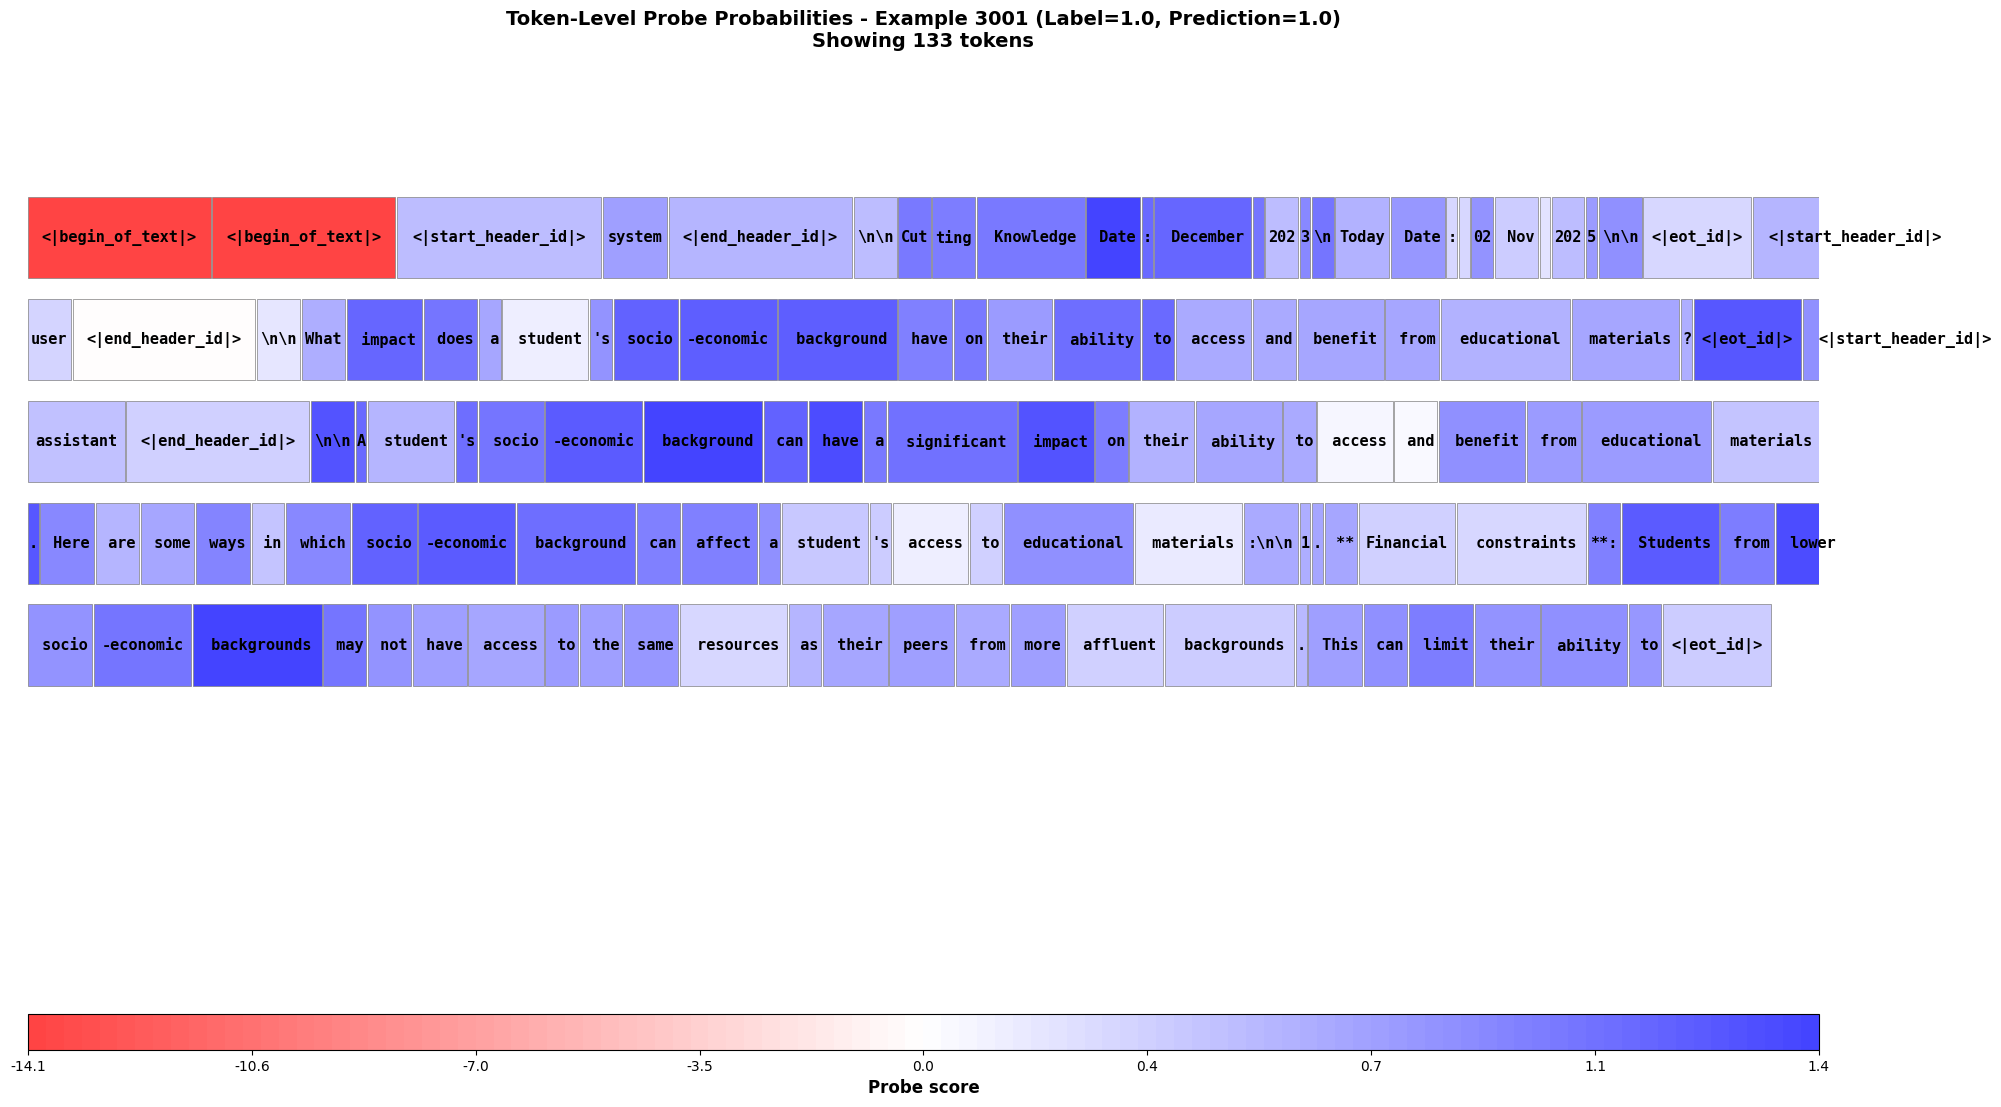

In [45]:
# from probe_gen.standard_experiments.token_heatmaps import visualize_token_heatmap

visualize_token_heatmap(
    tokenizer,
    3001,
    responses_df,
    activations_tensor,
    probe,
    labels_tensor,
)

In [ ]:
# Visualize multiple correctly classified examples
# Change num_examples_per_label to show more or fewer examples

num_examples_per_label = 10  # Number of examples to show for each label

# Visualize LABEL=1 examples
print("\n" + "="*100)
print(f"VISUALIZING {min(num_examples_per_label, len(correctly_classified_label_1))} CORRECTLY CLASSIFIED LABEL=1 EXAMPLES")
print("="*100)

for i in range(min(num_examples_per_label, len(correctly_classified_label_1))):
    print(f"\n{'#'*100}")
    print(f"LABEL=1 EXAMPLE {i+1}/{min(num_examples_per_label, len(correctly_classified_label_1))}")
    print(f"{'#'*100}")
    visualize_token_heatmap(correctly_classified_label_1[i], model_name = activations_model, dataset_name = datasource, behavior = behaviour, generation_method = generation_method, probe_type = probe_type)
    print("\n\n")

if len(correctly_classified_label_1) == 0:
    print("⚠️  No correctly classified label=1 examples available!")

# Visualize LABEL=0 examples
print("\n" + "="*100)
print(f"VISUALIZING {min(num_examples_per_label, len(correctly_classified_label_0))} CORRECTLY CLASSIFIED LABEL=0 EXAMPLES")
print("="*100)

for i in range(min(num_examples_per_label, len(correctly_classified_label_0))):
    print(f"\n{'#'*100}")
    print(f"LABEL=0 EXAMPLE {i+1}/{min(num_examples_per_label, len(correctly_classified_label_0))}")
    print(f"{'#'*100}")
    visualize_token_heatmap(correctly_classified_label_0[i])
    print("\n\n")

if len(correctly_classified_label_0) == 0:
    print("⚠️  No correctly classified label=0 examples available!")

print("="*100)
print(f"COMPLETED: Visualized {min(num_examples_per_label, len(correctly_classified_label_1))} label=1 + {min(num_examples_per_label, len(correctly_classified_label_0))} label=0 = {min(num_examples_per_label, len(correctly_classified_label_1)) + min(num_examples_per_label, len(correctly_classified_label_0))} total examples")
print("="*100)
